### Распаковка и подготовка данных

Исходный датасет содержит папки с названиями классов (включая квадратные скобки и пробелы). Приводим имена к читаемому виду для `ImageFolder`:
- `[Malignant] Pre-B` -> `pre_b`
- `[Malignant] early Pre-B` -> `early_pre_b`
- `[Malignant] Pro-B` -> `pro_b`
- `Benign` -> `benign`

In [ ]:
# распаковка
import zipfile, os
import os
import shutil
import random
from sklearn.model_selection import train_test_split

with zipfile.ZipFile('/content/Blood cell Cancer [ALL].zip', 'r') as z:
  z.extractall('/content/')

source_dir = '/content'
train_dir = '/content/train'
test_dir = '/content/test'
test_size = 0.2
random.seed(42)

classes = ['Benign', '[Malignant] Pre-B', '[Malignant] early Pre-B', '[Malignant] Pro-B']

for class_name in classes:
  clean_name = class_name.replace('[', '').replace(']', '').replace(' ', '_').replace('Malignant_', '').lower()
  if 'pre-b' in clean_name and 'early' not in clean_name: clean_name = 'pre_b'
  elif 'pro-b' in clean_name: clean_name = 'pro_b'
  elif 'early' in clean_name: clean_name = 'early_pre_b'
  elif 'benign' in clean_name: clean_name = 'benign'

  os.makedirs(os.path.join(train_dir, clean_name), exist_ok=True)
  os.makedirs(os.path.join(test_dir, clean_name), exist_ok=True)

  files = os.listdir(os.path.join(source_dir, class_name))
  train_files, test_files = train_test_split(files, test_size=test_size, random_state=42)

  for f in train_files:
    shutil.copy2(os.path.join(source_dir, class_name, f), os.path.join(train_dir, clean_name, f))
  for f in test_files:
    shutil.copy2(os.path.join(source_dir, class_name, f), os.path.join(test_dir, clean_name, f))

print("train:", os.listdir('/content/train')[:3])
print("test:", os.listdir('/content/test')[:3])

train: ['pre_b', 'benign', 'early_pre_b']
test: ['pre_b', 'benign', 'early_pre_b']


In [ ]:
print('train:')
print(f"benign: {len(os.listdir('/content/train/benign'))} файлов,", end= ' ')
print(f"early_pre_b: {len(os.listdir('/content/train/early_pre_b'))} файлов,", end= ' ')
print(f"pre_b: {len(os.listdir('/content/train/pre_b'))} файлов,", end= ' ')
print(f"pro_b: {len(os.listdir('/content/train/pro_b'))} файлов\n")

print('test:')
print(f"benign: {len(os.listdir('/content/test/benign'))} файлов,", end= ' ')
print(f"early_pre_b: {len(os.listdir('/content/test/early_pre_b'))} файлов,", end= ' ')
print(f"pre_b: {len(os.listdir('/content/test/pre_b'))} файлов,", end= ' ')
print(f"pro_b: {len(os.listdir('/content/test/pro_b'))} файлов")

train:
benign: 409 файлов, early_pre_b: 783 файлов, pre_b: 764 файлов, pro_b: 636 файлов

test:
benign: 103 файлов, early_pre_b: 196 файлов, pre_b: 191 файлов, pro_b: 160 файлов


### Аугментация и даталоадеры
- Train: Resize(128×128) + RandomRotation(10) + Normalize
- Test/Val: только Resize + Normalize (без аугментации)

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import numpy as np

train_transform = transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]
)

full_train_dataset = datasets.ImageFolder('/content/train', train_transform)
test_dataset = datasets.ImageFolder('/content/test', test_transform)

# train и val (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'классов: {len(full_train_dataset.classes)}')
print(f'train: {len(train_dataset)} изображений')
print(f'val: {len(val_dataset)} изображений')
print(f'test: {len(test_dataset)} изображений')

классов: 4
train: 2073 изображений
val: 519 изображений
test: 650 изображений


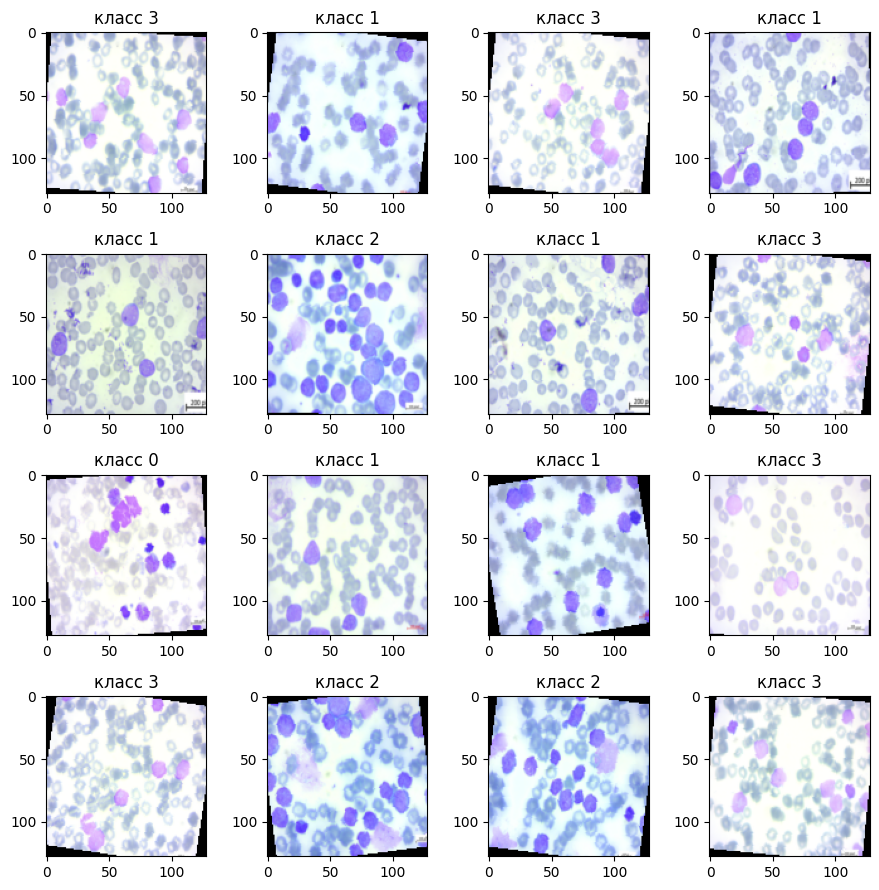

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

images, labels= next(iter(train_loader))

fig, axes=plt.subplots(4,4,figsize=(9,9))
axes=axes.ravel()

for i in range(16):
  img=images[i].permute(1,2,0).numpy()
  img=img*0.5 + 0.5
  img=np.clip(img,0,1)

  axes[i].imshow(img)
  axes[i].set_title(f'класс {labels[i].item()}')

plt.tight_layout()

### Три архитектуры для сравнения
- Simple CNN - 3 сверточных слоя, BatchNorm, без dropout
- CNN + Dropout - аналогичная архитектура с dropout (0.2–0.3)
- ResNet18 (pretrained) - замена последнего слоя на 4 класса

In [ ]:
from sklearn import model_selection
from torch.nn import Sequential, Conv2d, MaxPool2d, Flatten, Linear, ReLU, BatchNorm2d, Dropout
from torchvision import models

model1=Sequential(
    Conv2d(3,32, kernel_size=3,padding=1), #[32, 128, 128]
    BatchNorm2d(32),
    ReLU(),
    MaxPool2d(2), #[32, 64, 64]

    Conv2d(32, 64, kernel_size=3, padding=1), #[64,64,64]
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2), #[64, 32,32]

    Conv2d(64, 128, kernel_size=3, padding=1), #[128, 32, 32]
    BatchNorm2d(128),
    ReLU(),
    MaxPool2d(2), #[128, 16, 16]

    Flatten(),
    Linear(128*16*16, 256),
    ReLU(),
    Linear(256, 4)
)

model2=Sequential(
    Conv2d(3,32,kernel_size=3, padding=1),
    BatchNorm2d(32),
    ReLU(),
    MaxPool2d(2),

    Conv2d(32, 64, kernel_size=3, padding=1),
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2),
    Dropout(0.2),

    Conv2d(64, 128, kernel_size=3, padding=1),
    BatchNorm2d(128),
    ReLU(),
    MaxPool2d(2),
    Dropout(0.2),

    Flatten(),
    Linear(128*16*16, 256),
    ReLU(),
    Dropout(0.3),
    Linear(256,4)
)

model3=models.resnet18(pretrained=True)
model3.fc=Linear(model3.fc.in_features, 4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


### Функция обучения
- Метрика: weighted F1-score (учитывает дисбаланс классов)
- Сохраняется лучшая модель по F1 на валидации
- Визуализация loss и F1 по эпохам

In [ ]:
from torch.nn import CrossEntropyLoss
from torch import optim
from sklearn.metrics import f1_score

loss_f=CrossEntropyLoss()
optimizer1=optim.Adam(model1.parameters())
optimizer2=optim.Adam(model2.parameters())
optimizer3=optim.Adam(model3.parameters())

def train_model(model,optimizer,ep, model_name='model'):
  best_f1=0
  train_losses = []
  val_losses = []
  train_f1s = []
  val_f1s = []
  for epoch in range(ep):
    model.train()
    loss_ep_tr=0
    train_preds=[]
    train_labels=[]
    for x_tr, y_tr in train_loader:
      y_pred_raw=model(x_tr)
      loss=loss_f(y_pred_raw, y_tr)
      loss_ep_tr+=loss.item()

      y_pred=torch.max(y_pred_raw, 1)[1]
      train_preds.extend(y_pred.cpu().numpy())
      train_labels.extend(y_tr.cpu().numpy())

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    train_f1 = f1_score(train_labels, train_preds, average='weighted')
    train_loss = loss_ep_tr / len(train_loader)
    train_losses.append(train_loss)
    train_f1s.append(train_f1)


    model.eval()
    loss_ep_val=0
    val_preds = []
    val_labels = []
    for x_val, y_val in val_loader:
      y_pr_raw=model(x_val)
      loss_v=loss_f(y_pr_raw, y_val)
      loss_ep_val+=loss_v.item()

      y_pr=torch.max(y_pr_raw,1)[1]
      val_preds.extend(y_pr.cpu().numpy())
      val_labels.extend(y_val.cpu().numpy())

    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    val_loss = loss_ep_val / len(val_loader)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)

    print(f'эпоха {epoch+1}:')
    print(f'train: loss = {train_loss:.4f}, f1 = {train_f1:.3f}')
    print(f'val: loss = {val_loss:.4f}, f1 = {val_f1:.3f}')

    if val_f1>best_f1:
      best_f1=val_f1
      torch.save(model.state_dict(), f'best_{model_name}.pth')


  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  plt.plot(range(1, ep+1), train_losses, marker='o', label='train')
  plt.plot(range(1, ep+1), val_losses, marker='o', label='validation')
  plt.title('loss по эпохам')
  plt.xlabel('эпоха')
  plt.ylabel('loss')
  plt.legend()
  plt.grid(True)

  plt.subplot(1,2,2)
  plt.plot(range(1, ep+1), train_f1s, marker='o', label='train', color='green')
  plt.plot(range(1, ep+1), val_f1s, marker='o', label='validation', color='orange')
  plt.title('f1-score по эпохам')
  plt.xlabel('эпоха')
  plt.ylabel('f1')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

  model.load_state_dict(torch.load(f'best_{model_name}.pth'))
  return model

эпоха 1:
train: loss = 0.2518, f1 = 0.929
val: loss = 0.4339, f1 = 0.894
эпоха 2:
train: loss = 0.1172, f1 = 0.964
val: loss = 0.4607, f1 = 0.859
эпоха 3:
train: loss = 0.2315, f1 = 0.942
val: loss = 0.1350, f1 = 0.960
эпоха 4:
train: loss = 0.1071, f1 = 0.965
val: loss = 2.4349, f1 = 0.645
эпоха 5:
train: loss = 0.1780, f1 = 0.944
val: loss = 0.0567, f1 = 0.977
эпоха 6:
train: loss = 0.0962, f1 = 0.969
val: loss = 0.2666, f1 = 0.910
эпоха 7:
train: loss = 0.0545, f1 = 0.980
val: loss = 0.0349, f1 = 0.983
эпоха 8:
train: loss = 0.0297, f1 = 0.989
val: loss = 0.0490, f1 = 0.981
эпоха 9:
train: loss = 0.0457, f1 = 0.986
val: loss = 0.0464, f1 = 0.981
эпоха 10:
train: loss = 0.0174, f1 = 0.994
val: loss = 0.0697, f1 = 0.977


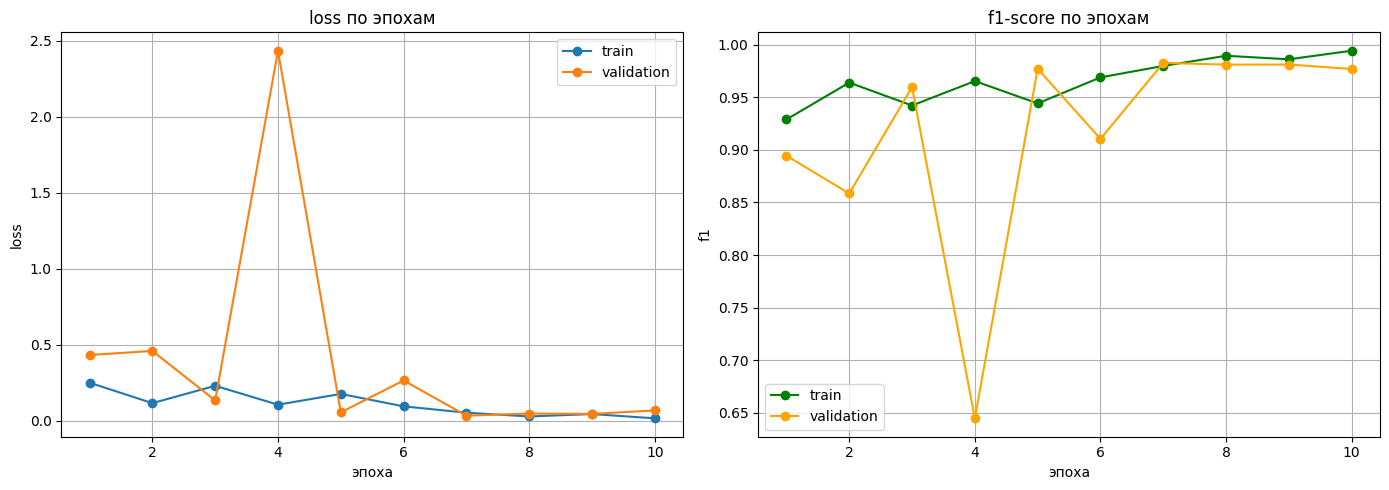

In [ ]:
model1=train_model(model1, optimizer1, 10, model_name='model1')

эпоха 1:
train: loss = 1.9087, f1 = 0.614
val: loss = 0.5661, f1 = 0.763
эпоха 2:
train: loss = 0.5315, f1 = 0.742
val: loss = 1.0079, f1 = 0.642
эпоха 3:
train: loss = 0.4551, f1 = 0.807
val: loss = 0.5672, f1 = 0.790
эпоха 4:
train: loss = 0.3770, f1 = 0.850
val: loss = 0.4931, f1 = 0.793
эпоха 5:
train: loss = 0.2852, f1 = 0.900
val: loss = 0.2957, f1 = 0.890
эпоха 6:
train: loss = 0.2328, f1 = 0.926
val: loss = 0.1770, f1 = 0.949
эпоха 7:
train: loss = 0.1546, f1 = 0.953
val: loss = 0.1679, f1 = 0.943
эпоха 8:
train: loss = 0.1550, f1 = 0.954
val: loss = 0.0744, f1 = 0.986
эпоха 9:
train: loss = 0.1370, f1 = 0.956
val: loss = 6.0867, f1 = 0.481
эпоха 10:
train: loss = 0.1242, f1 = 0.960
val: loss = 0.1439, f1 = 0.961


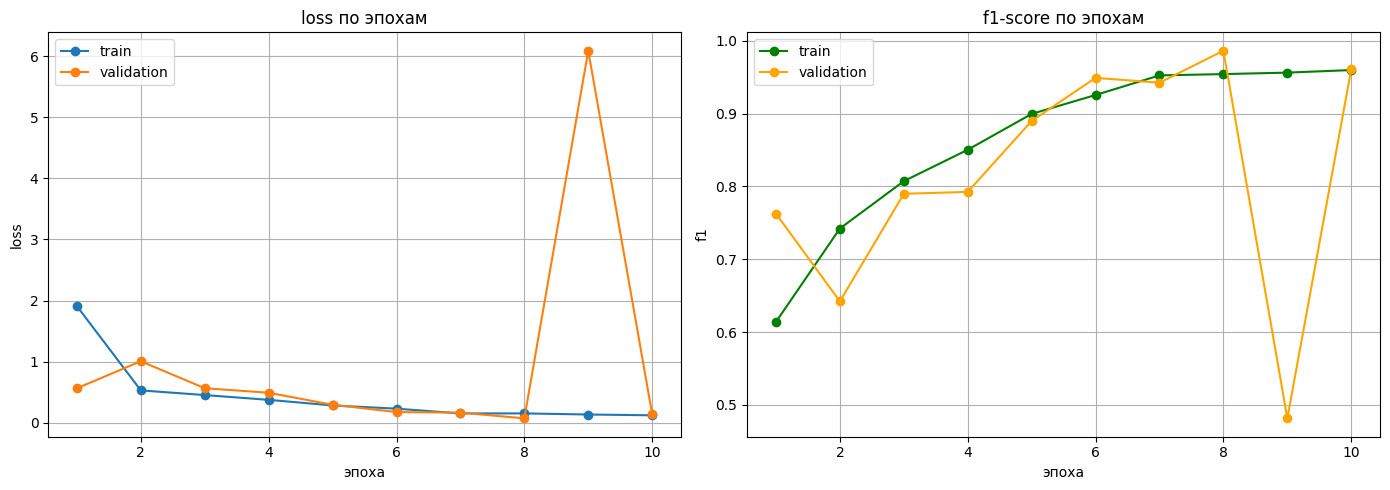

In [ ]:
model2=train_model(model2, optimizer2, 10, model_name='model2')

эпоха 1:
train: loss = 0.2852, f1 = 0.907
val: loss = 0.1704, f1 = 0.925
эпоха 2:
train: loss = 0.1157, f1 = 0.967
val: loss = 0.0822, f1 = 0.977
эпоха 3:
train: loss = 0.0966, f1 = 0.970
val: loss = 0.1195, f1 = 0.965
эпоха 4:
train: loss = 0.0635, f1 = 0.983
val: loss = 0.0377, f1 = 0.996
эпоха 5:
train: loss = 0.0631, f1 = 0.978
val: loss = 0.0844, f1 = 0.966
эпоха 6:
train: loss = 0.0621, f1 = 0.979
val: loss = 0.0493, f1 = 0.988
эпоха 7:
train: loss = 0.0240, f1 = 0.991
val: loss = 0.0121, f1 = 0.996
эпоха 8:
train: loss = 0.0219, f1 = 0.993
val: loss = 0.0575, f1 = 0.985
эпоха 9:
train: loss = 0.0323, f1 = 0.989
val: loss = 0.0385, f1 = 0.985
эпоха 10:
train: loss = 0.0449, f1 = 0.985
val: loss = 0.0509, f1 = 0.987


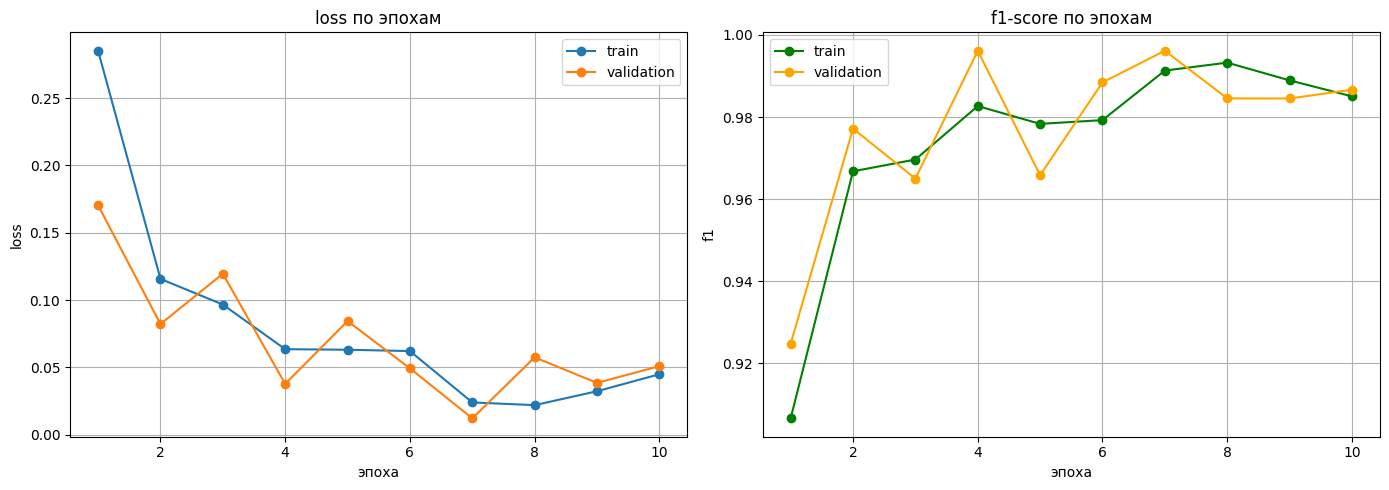

In [ ]:
model3=train_model(model3, optimizer3, 10, model_name='model3')

### Тестирование модели
Функция `test_model()` вычисляет weighted F1, classification report и строит confusion matrix.

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def test_model(model, class_names):
  model.eval()
  all_preds=[]
  all_labels=[]

  with torch.no_grad():
    for x_te, y_te in test_loader:
      y_pr=torch.max(model(x_te), 1)[1]

      all_preds.extend(y_pr.cpu().numpy())
      all_labels.extend(y_te.cpu().numpy())

  f1=f1_score(all_labels, all_preds, average='weighted')
  print(f'f1-score: {f1:.3f}\n')
  print(f'classification report:\n{classification_report(all_labels, all_preds, target_names=class_names)}\n')

  plt.figure(figsize=(8,6))
  conf=confusion_matrix(all_labels, all_preds)
  sns.heatmap(conf, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
  plt.title('confusion matrix')
  plt.xlabel('predicted')
  plt.ylabel('true')
  plt.show()
  plt.tight_layout()

  return f1


class_names=train_dataset.dataset.classes

f1-score: 0.994

classification report:
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98       103
 early_pre_b       0.99      0.99      0.99       196
       pre_b       1.00      1.00      1.00       191
       pro_b       1.00      1.00      1.00       160

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650




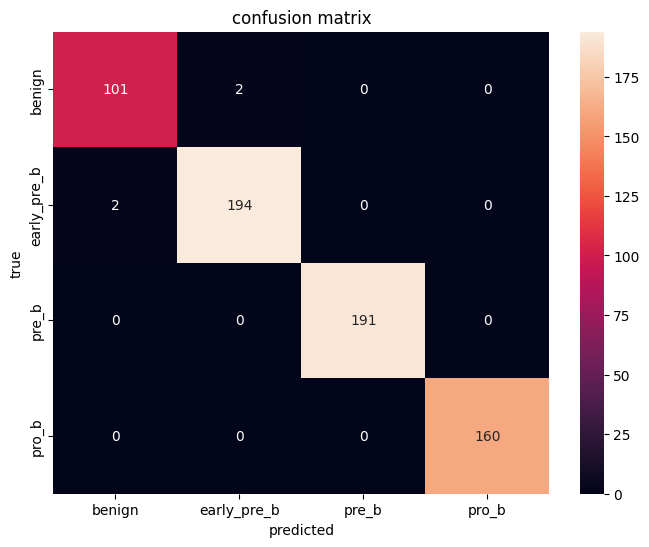

<Figure size 640x480 with 0 Axes>

In [ ]:
f1_1=test_model(model1, class_names)

f1-score: 0.977

classification report:
              precision    recall  f1-score   support

      benign       0.96      0.90      0.93       103
 early_pre_b       0.97      0.99      0.98       196
       pre_b       0.99      0.98      0.99       191
       pro_b       0.98      1.00      0.99       160

    accuracy                           0.98       650
   macro avg       0.97      0.97      0.97       650
weighted avg       0.98      0.98      0.98       650




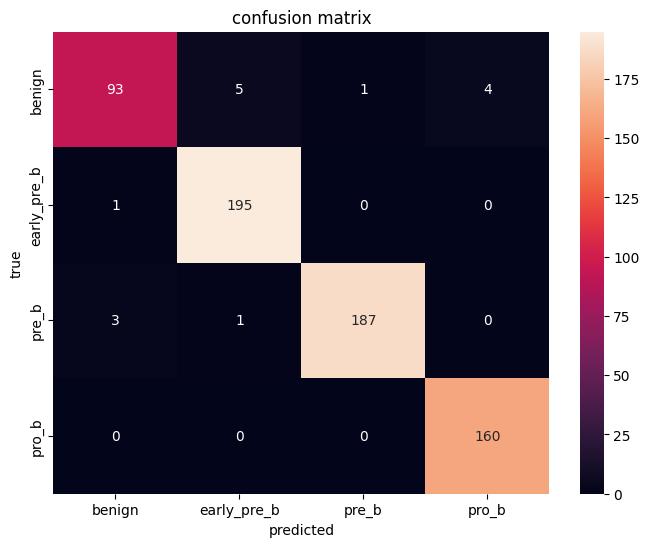

<Figure size 640x480 with 0 Axes>

In [ ]:
f1_2=test_model(model2, class_names)

f1-score: 0.998

classification report:
              precision    recall  f1-score   support

      benign       0.99      1.00      1.00       103
 early_pre_b       1.00      0.99      1.00       196
       pre_b       1.00      1.00      1.00       191
       pro_b       1.00      1.00      1.00       160

    accuracy                           1.00       650
   macro avg       1.00      1.00      1.00       650
weighted avg       1.00      1.00      1.00       650




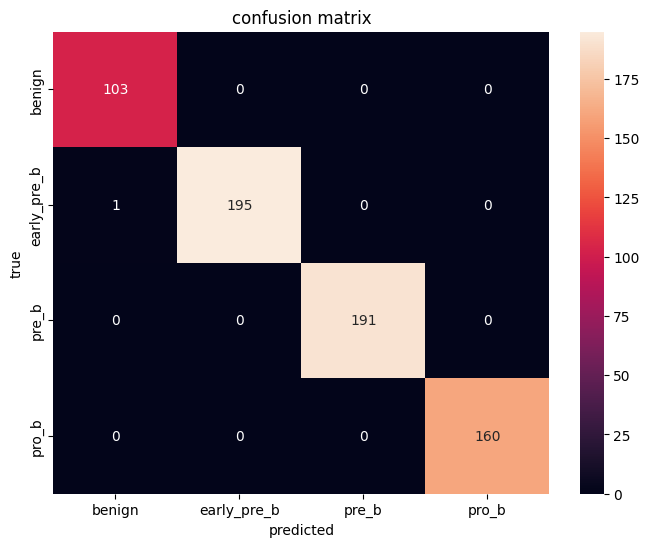

<Figure size 640x480 with 0 Axes>

In [ ]:
f1_3=test_model(model3, class_names)